In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd

import kind
import ex_duffing
import util_data

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--file_dir', '../../data/dreamer',
        '--file_name', 'duffing',
        '--data_nsample_nom', '253',
        '--data_nsample_exc', '460',
        '--feature_ndim', '4',
        '--target_ndim', '2',
        '--data_train_size', '0.9',

        '--back_nsample', '64',
        '--fore_nsample', '32',

        '--batch_size', '64',
        '--learning_rate', '0.002',
        '--weight_decay', '0.000001',
        '--nepoch', '1000',
        '--patience', '100',
        '--checkpoints', '../../models/dreamer',

        '--rez_nsample_nom', '32',
        '--rez_nsample_exc', '16',
        '--embed_nom', '{"sin": 6, "cos": 6}',
        '--embed_exc', '{"data": 12}',
    ]
)

setpoint = [1.0, 0.0]

In [3]:
model = kind.model(args)

dataset = ex_duffing.dataset(
    args.file_dir, args.file_name, args.file_index, args.file_ext,
    args.data_nsample_nom, args.data_nsample_exc,
    (args.data_train_size, args.data_test_size),
    args.batch_size, (args.back_nsample, args.fore_nsample), setpoint, load_normalized=True)

training = kind.training(model)

In [4]:
_, _, data_loader = dataset.load(data_type='mixed')

data_path = '../../data/dreamer/duffing_all_0.csv'
dataframe = pd.read_csv(data_path, header=None, dtype=np.float32)
replay = torch.unsqueeze(torch.from_numpy(dataframe.to_numpy()), 0)
print(replay.shape)

torch.Size([1, 619, 4])


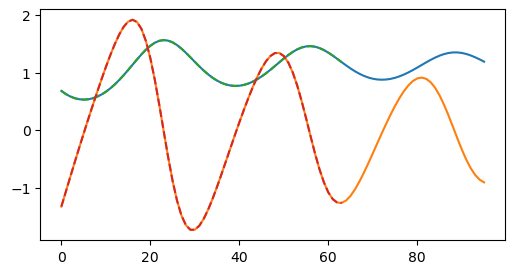

In [5]:
jdata = 3
offset = 90

with torch.no_grad():
    for back_n, fore_n in data_loader:
        true_n = torch.cat([back_n, fore_n], dim=1)

        true = replay[:, offset:offset + args.back_nsample + args.fore_nsample]
        back = replay[:, offset:offset + args.back_nsample]

        true = dataset.normalizer.normalize(true)
        back = dataset.normalizer.normalize(back)

        plt.figure(figsize=(6,3))
        plt.plot(true[0, :, :2])
        plt.plot(back[0, :, :2], linestyle='dashed')
        break

#print(tata.shape)

In [6]:
model.train()
training.fit(dataset)

>>> training nominal mean >>>
	epoch 1 losses: train=1.219952, valid=1.128252, test=1.244896
	validation loss decreased (inf -> 1.128252), saving model ...
	epoch 2 losses: train=1.138424, valid=1.095383, test=1.215310
	validation loss decreased (1.128252 -> 1.095383), saving model ...
	epoch 3 losses: train=1.108435, valid=1.053345, test=1.176385
	validation loss decreased (1.095383 -> 1.053345), saving model ...
	epoch 4 losses: train=1.046777, valid=0.999380, test=1.127259
	validation loss decreased (1.053345 -> 0.999380), saving model ...
	epoch 5 losses: train=1.017675, valid=0.936978, test=1.075522
	validation loss decreased (0.999380 -> 0.936978), saving model ...
	epoch 6 losses: train=0.939642, valid=0.876782, test=1.034705
	validation loss decreased (0.936978 -> 0.876782), saving model ...
	epoch 7 losses: train=0.865402, valid=0.831809, test=1.013658
	validation loss decreased (0.876782 -> 0.831809), saving model ...
	epoch 8 losses: train=0.782863, valid=0.799656, test=0.98

In [7]:
model.eval()
data_loader, _, _ = dataset.load(data_type='nom')

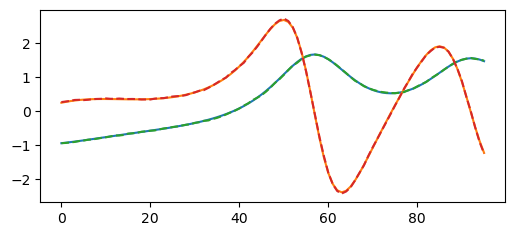

NameError: name 'tata' is not defined

In [24]:
jdata = 15

with torch.no_grad():
    for back, fore in data_loader:
        true = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        mean_nom = model_o.mean_nom

        plt.figure(figsize=(6,2.5))
        plt.plot(true[jdata, :, :2])
        plt.plot(mean_nom[0, :, :2], linestyle='dashed')

        plt.show()

        break

print(tata.shape)

In [25]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training nominal uncertainty >>>
	epoch 1 losses: train=1.096074, valid=1.032290, test=0.981582
	validation loss decreased (inf -> 1.032290), saving model ...
	epoch 2 losses: train=1.059398, valid=0.984375, test=0.939330
	validation loss decreased (1.032290 -> 0.984375), saving model ...
	epoch 3 losses: train=1.017338, valid=0.922972, test=0.891029
	validation loss decreased (0.984375 -> 0.922972), saving model ...
	epoch 4 losses: train=1.005924, valid=0.864811, test=0.881671
	validation loss decreased (0.922972 -> 0.864811), saving model ...
	epoch 5 losses: train=0.936141, valid=0.810217, test=0.827242
	validation loss decreased (0.864811 -> 0.810217), saving model ...
	epoch 6 losses: train=0.900378, valid=0.836113, test=0.826236
	early stopping counter: 1 out of 100
	epoch 7 losses: train=0.923788, valid=0.782321, test=0.785398
	validation loss decreased (0.810217 -> 0.782321), saving model ...
	epoch 8 losses: train=0.802678, valid=0.677409, test=0.733045
	validation loss d

In [26]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

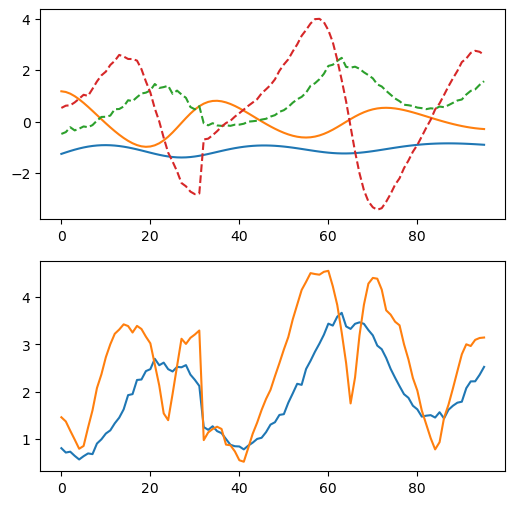

In [32]:
jdata = 5

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        stat = model_o.mean_nom
        zeta_nom = model_o.zeta_nom

        plt.figure(figsize=(6,6))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(zeta_nom[0, :, :2])

        plt.show()

        break

#print(tata.shape)

In [33]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion mean >>>
	epoch 1 losses: train=0.911280, valid=0.983887, test=0.821613
	validation loss decreased (inf -> 0.983887), saving model ...
	epoch 2 losses: train=0.834450, valid=0.928311, test=0.806341
	validation loss decreased (0.983887 -> 0.928311), saving model ...
	epoch 3 losses: train=0.838423, valid=0.842284, test=0.770180
	validation loss decreased (0.928311 -> 0.842284), saving model ...
	epoch 4 losses: train=0.733957, valid=0.743388, test=0.653954
	validation loss decreased (0.842284 -> 0.743388), saving model ...
	epoch 5 losses: train=0.647198, valid=0.685754, test=0.595834
	validation loss decreased (0.743388 -> 0.685754), saving model ...
	epoch 6 losses: train=0.571256, valid=0.657339, test=0.546638
	validation loss decreased (0.685754 -> 0.657339), saving model ...
	epoch 7 losses: train=0.547153, valid=0.620488, test=0.496793
	validation loss decreased (0.657339 -> 0.620488), saving model ...
	epoch 8 losses: train=0.498316, valid=0.589200, test=0.

In [34]:
model.eval()
_, _, data_loader = dataset.load(data_type='exc')

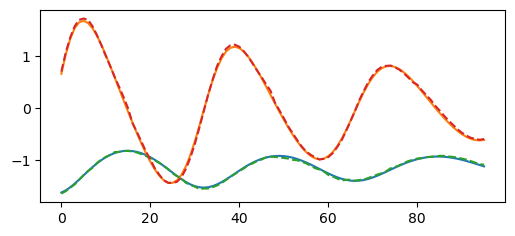

In [42]:
jdata = 7

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        stat = model_o.mean_exc

        plt.figure(figsize=(6,2.5))
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.show()

        break

In [43]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion uncertainty >>>
	epoch 1 losses: train=0.346948, valid=0.462525, test=0.622553
	validation loss decreased (inf -> 0.462525), saving model ...
	epoch 2 losses: train=0.330185, valid=0.449922, test=0.600286
	validation loss decreased (0.462525 -> 0.449922), saving model ...
	epoch 3 losses: train=0.347038, valid=0.446414, test=0.591605
	validation loss decreased (0.449922 -> 0.446414), saving model ...
	epoch 4 losses: train=0.335636, valid=0.445485, test=0.590917
	validation loss decreased (0.446414 -> 0.445485), saving model ...
	epoch 5 losses: train=0.323417, valid=0.445166, test=0.590914
	validation loss decreased (0.445485 -> 0.445166), saving model ...
	epoch 6 losses: train=0.341772, valid=0.444905, test=0.591783
	validation loss decreased (0.445166 -> 0.444905), saving model ...
	epoch 7 losses: train=0.326078, valid=0.444642, test=0.590985
	validation loss decreased (0.444905 -> 0.444642), saving model ...
	epoch 8 losses: train=0.328056, valid=0.444471, 

In [44]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

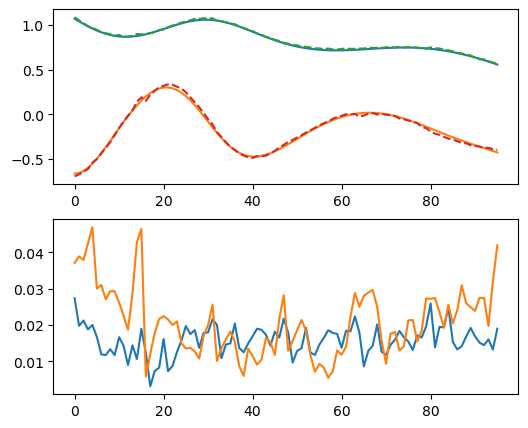

In [50]:
jdata = 5

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        exc = model_o.mean_exc
        exc_u = model_o.zeta_exc

        plt.figure(figsize=(6,5))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(exc[0, :, :2], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(exc_u[0, :, :2])

        plt.show()

        break

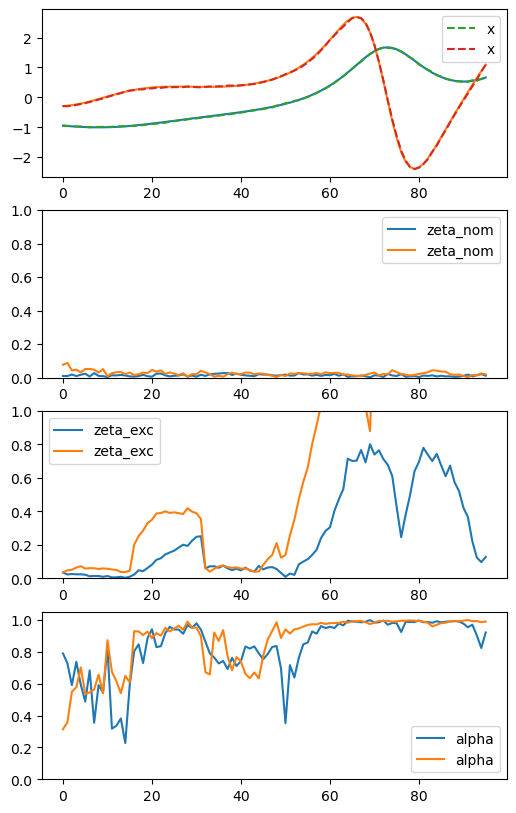

In [55]:
jdata = 4

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        pre = model_o.blend
        u_nom = model_o.zeta_nom
        u_exc = model_o.zeta_exc
        alpha = model_o.alpha

        plt.figure(figsize=(6,10))

        plt.subplot(4,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(pre[0, :, :2], linestyle='dashed', label='x')
        plt.legend()

        plt.subplot(4,1,2)
        plt.plot(u_nom[0, :, :2], label='zeta_nom')
        plt.ylim((0,1))
        plt.legend()

        plt.subplot(4,1,3)
        plt.plot(u_exc[0, :, :2], label='zeta_exc')
        plt.ylim((0,1))
        plt.legend()

        plt.subplot(4,1,4)
        plt.plot(alpha[0, :, :2], label='alpha')
        plt.ylim((0.0, 1.05))
        plt.legend()

        plt.show()

        break